# Tutorial — pacote `yggdrasil`

Este notebook é um **passeio guiado** pela biblioteca `yggdrasil`: uma esteira de Machine
Learning governada (estilo risco de crédito) com MLflow. Vamos usar **cada peça isoladamente**
(métricas, ratings, PSI, SHAP, relatórios) e, no fim, ver como o `MLPipeline` faz tudo de uma vez.

**Pré-requisito:** instalar o pacote em modo editável.

```bash
pip install -e ".[dev]"
```

> O dataset é sintético (gerado aqui), então o notebook roda de ponta a ponta sem dados externos.

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd

# Backend de arquivos local do MLflow 3.x (no Databricks isto é desnecessário).
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RANDOM_STATE = 42

## 1. O contrato de dados

A esteira recebe **uma tabela** (pandas) com quatro tipos de coluna:

| Papel | Padrão | Descrição |
|---|---|---|
| Features | prefixo `feat_` | variáveis explicativas |
| Data/safra | `dt_ref` | usada no PSI ao longo do tempo |
| Amostra | `amostra` | `DES`/`OOT` (análise) e, opcionalmente, `SIMUL`/`BACKTEST` (só score) |
| Resposta | `target` | variável a ser modelada (0/1 ou contínua) |

Vamos gerar um dataset sintético de **classificação** (ex.: PD — probabilidade de default) com
12 safras mensais, amostras `DES` (desenvolvimento), `OOT` (out-of-time) e um pouco de `SIMUL`.

In [2]:
from sklearn.datasets import make_classification

n = 4000
X, y = make_classification(
    n_samples=n, n_features=7, n_informative=5, weights=[0.85],
    random_state=RANDOM_STATE,
)

rng = np.random.default_rng(RANDOM_STATE)
meses = pd.date_range("2023-01-01", periods=12, freq="MS")

df = pd.DataFrame(X, columns=[f"feat_{i:02d}" for i in range(7)])
df["target"] = y
df["dt_ref"] = rng.choice(meses, size=n)
df["amostra"] = np.where(df["dt_ref"] >= meses[8], "OOT", "DES")
# 5% das linhas viram SIMUL (scoring-only): recebem score + rating, sem análise.
df.loc[df.sample(frac=0.05, random_state=1).index, "amostra"] = "SIMUL"

print("Distribuição das amostras:")
display(df["amostra"].value_counts())
print("Taxa de evento (target=1):", round(df["target"].mean(), 3))
df.head()

Distribuição das amostras:


amostra
DES      2524
OOT      1276
SIMUL     200
Name: count, dtype: int64

Taxa de evento (target=1): 0.152


,feat_00,feat_01,feat_02,feat_03,feat_04,feat_05,feat_06,target,dt_ref,amostra
0,-0.8244,1.3450,1.3094,-1.6740,-0.7322,0.1758,1.9429,0,2023-02-01,DES
1,-0.6652,2.3784,0.2257,-1.8743,-0.0439,0.2274,2.4384,0,2023-10-01,OOT
2,0.7175,-1.3094,1.7416,0.2241,-0.5919,0.2889,-0.7190,1,2023-08-01,DES
3,-0.6760,2.2756,-0.0368,-2.1812,-0.2157,0.1150,2.6103,0,2023-06-01,DES
4,-1.0381,1.2003,-0.3543,-2.7731,-0.8886,-0.8370,2.7483,0,2023-06-01,DES


## 2. `ColumnConfig` — dizendo à esteira quem é quem

`ColumnConfig` mapeia os nomes das colunas e define quais amostras recebem análise completa
(`analysis_samples`). Tudo que estiver fora dessa lista é **scoring-only**.

In [3]:
from yggdrasil import ColumnConfig
from yggdrasil.data import analysis_samples_present, scoring_only_samples_present

cfg = ColumnConfig()  # usa os padrões: feat_, dt_ref, amostra, target, (DES, OOT)
print("Features detectadas:", cfg.feature_columns(df))
print("Amostras de análise :", analysis_samples_present(df, cfg))
print("Scoring-only        :", scoring_only_samples_present(df, cfg))

Features detectadas: ['feat_00', 'feat_01', 'feat_02', 'feat_03', 'feat_04', 'feat_05', 'feat_06']
Amostras de análise : ['DES', 'OOT']
Scoring-only        : ['SIMUL']


## 3. Treinar um modelo (a esteira é agnóstica)

O `yggdrasil` **não** treina o modelo por você (a menos que use o `PyCaretTrainer` opcional):
você traz qualquer estimador sklearn-like já treinado. Aqui usamos um `RandomForestClassifier`
treinado **apenas na amostra DES** e geramos o score (probabilidade) para todas as linhas.

In [4]:
from sklearn.ensemble import RandomForestClassifier

feats = cfg.feature_columns(df)
treino = df[df["amostra"] == cfg.dev_sample]

model = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(treino[feats], treino["target"])

# score = probabilidade da classe positiva, gravado na coluna cfg.score_col ('prediction')
df[cfg.score_col] = model.predict_proba(df[feats])[:, 1]

# Slices reutilizados adiante — derivados DEPOIS do score (já contêm 'prediction').
dev = df[df["amostra"] == cfg.dev_sample]
oot = df[df["amostra"] == cfg.oot_sample]
df[["amostra", "target", cfg.score_col]].head()

,amostra,target,prediction
0,DES,0,0.0067
1,OOT,0,0.0067
2,DES,1,0.8333
3,DES,0,0.0000
4,DES,0,0.0000


## 4. Métricas por amostra e *shifts*

`metric_by_sample` calcula o pacote de métricas para cada amostra de análise (DES/OOT).
Para classificação: **KS, AUC, Gini, Acurácia, F1, precisão, recall, Brier, logloss**
(o limiar de corte para Acc/F1 é o KS-ótimo estimado no DES e reaplicado no OOT).

`sample_shifts` mede o deslocamento DES→OOT de cada métrica (degradação fora do tempo).

In [5]:
from yggdrasil.metrics import metric_by_sample, sample_shifts

df_analise = df[df["amostra"].isin(cfg.analysis_samples)]

met = metric_by_sample(df_analise, cfg, "classification")
print("Métricas por amostra:")
display(pd.DataFrame(met).T)

print("Shifts DES -> OOT:")
display(pd.Series(sample_shifts(met, cfg), name="shift").to_frame())

Métricas por amostra:


,auc,gini,ks,ks_cutoff,accuracy,f1,precision,recall,brier,logloss
DES,1.0000,1.0000,1.0000,0.6067,1.0000,1.0000,1.0000,1.0000,0.0050,0.0364
OOT,0.9778,0.9555,0.8694,0.6067,0.9350,0.7608,0.9496,0.6346,0.0420,0.1457


Shifts DES -> OOT:


,shift
auc_shift_abs,-0.0222
auc_shift_rel,-0.0222
gini_shift_abs,-0.0445
gini_shift_rel,-0.0445
ks_shift_abs,-0.1306
ks_shift_rel,-0.1306
accuracy_shift_abs,-0.0650
accuracy_shift_rel,-0.0650
f1_shift_abs,-0.2392
f1_shift_rel,-0.2392


In [6]:
# As funções de baixo nível também estão disponíveis avulsas:
from yggdrasil.metrics import classification_metrics, ks_statistic, ks_optimal_cutoff

print("KS no OOT      :", round(ks_statistic(oot["target"], oot[cfg.score_col]), 4))
print("Cutoff KS-ótimo:", round(ks_optimal_cutoff(dev["target"], dev[cfg.score_col]), 4))

KS no OOT      : 0.8694
Cutoff KS-ótimo: 0.6067


## 5. Grupos homogêneos (ratings)

Um *rating* agrupa o score previsto em faixas ordenadas (como notas de risco A, B, C…).
O pacote traz **4 metodologias**:

- `decis` — 10 faixas por quantil (rótulos `R01..R10`), sem fusão;
- `quantil` — quantis finos (0.05) + **fusão monotônica por inversão** (Mann-Whitney no OOT);
- `arvore` — `DecisionTree` (score → target) + fusão monotônica;
- `optbin` — binning ótimo (OptBinning), já monotônico.

Cada estratégia aprende os cortes **no DES** (`fit`) e aplica em qualquer amostra (`transform`).

In [7]:
from yggdrasil.ratings import DecileRating

decis = DecileRating()
df["rating_decis"] = decis.fit_transform(df, cfg, "classification")

print("Grupos do decis:", decis.labels_)
print("Taxa de evento média por grupo (DES):")
display(
    df[df["amostra"] == "DES"]
    .groupby("rating_decis")["target"].mean().to_frame("event_rate")
)

Grupos do decis: ['R01', 'R02', 'R03', 'R04', 'R05', 'R06']
Taxa de evento média por grupo (DES):


,event_rate
rating_decis,
R01,0.0000
R02,0.0000
R03,0.0000
R04,0.0000
R05,0.4692
R06,1.0000


In [8]:
# Aplicando as 4 metodologias de uma vez via build_ratings()
from yggdrasil.ratings import build_ratings

for strat in build_ratings(["decis", "quantil", "arvore", "optbin"]):
    df[strat.column] = strat.fit_transform(df, cfg, "classification")
    print(f"{strat.name:8s} -> {len(strat.labels_)} grupos: {strat.labels_}")

# Atualiza o recorte de análise para já incluir as colunas de rating.
df_analise = df[df["amostra"].isin(cfg.analysis_samples)].copy()
rating_cols = ["rating_decis", "rating_quantil", "rating_arvore", "rating_optbin"]

decis    -> 6 grupos: ['R01', 'R02', 'R03', 'R04', 'R05', 'R06']
quantil  -> 7 grupos: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
arvore   -> 2 grupos: ['A', 'B']


optbin   -> 1 grupos: ['A']


## 6. PSI — estabilidade no tempo

O **Population Stability Index** mede o deslocamento de uma distribuição contra uma referência
(o DES). Faixas usuais: `<0.10` estável, `0.10–0.25` atenção, `>0.25` instável.

- `psi` — PSI numérico (ex.: do score) DES vs OOT;
- `psi_summary` — PSI agregado do score e de cada rating (vira métrica no MLflow);
- `psi_rating_over_time` — série mensal do PSI de um rating (vira artefato no MLflow).

In [9]:
from yggdrasil.monitoring import psi, psi_summary, psi_rating_over_time, classify_psi

p_score = psi(dev[cfg.score_col], oot[cfg.score_col])
print(f"PSI do score (DES->OOT): {p_score:.4f}  [{classify_psi(p_score)}]")

print("PSI agregado (DES->OOT):")
display(pd.Series(psi_summary(df_analise, cfg, rating_cols), name="psi").to_frame())

PSI do score (DES->OOT): 0.2674  [instavel]
PSI agregado (DES->OOT):


,psi
psi_score_oot,0.2674
psi_rating_decis_oot,0.2674
psi_rating_quantil_oot,0.2642
psi_rating_arvore_oot,0.0024
psi_rating_optbin_oot,0.0000


In [10]:
# PSI do rating 'decis' ao longo das safras (contra a baseline do DES)
display(psi_rating_over_time(df, "rating_decis", cfg))

,mes,psi,n,flag
0,2023-01-01,0.0261,297,estavel
1,2023-02-01,0.0122,375,estavel
2,2023-03-01,0.0261,346,estavel
3,2023-04-01,0.0102,317,estavel
4,2023-05-01,0.0347,319,estavel
5,2023-06-01,0.0040,352,estavel
6,2023-07-01,0.0069,341,estavel
7,2023-08-01,0.0043,320,estavel
8,2023-09-01,0.2543,321,instavel
9,2023-10-01,0.2405,338,atencao


## 7. SHAP — interpretabilidade

`shap_feature_importance` resume a importância global (média de |SHAP|). `compute_shap`
calcula a matriz de valores (TreeExplainer/Linear/Kernel, escolhido automaticamente).

In [11]:
from yggdrasil.interpretability import compute_shap, shap_feature_importance

shap_values, X_amostra = compute_shap(model, dev[feats], problem_type="classification",
                                      sample_size=1000)
importancia = shap_feature_importance(shap_values, feats)
print("Importância por feature (SHAP):")
display(importancia)

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


 52%|==========          | 1037/2000 [00:11<00:10]       

 57%|===========         | 1135/2000 [00:12<00:09]       

 62%|============        | 1237/2000 [00:13<00:08]       

 66%|=============       | 1313/2000 [00:14<00:07]       

...

 95%|=================== | 1897/2000 [00:29<00:01]       

 97%|=================== | 1934/2000 [00:30<00:01]       

 99%|===================| 1974/2000 [00:31<00:00]       

Importância por feature (SHAP):


,feature,mean_abs_shap
0,feat_02,0.0616
1,feat_00,0.0587
2,feat_06,0.0541
3,feat_01,0.0412
4,feat_04,0.0341
5,feat_03,0.0220
6,feat_05,0.0213


## 8. Relatório por grupo homogêneo + dashboard

`group_report` produz a tabela analítica por grupo: volume, representatividade (global e por
amostra), **média prevista** (score) e **média observada** (target), faixa de score e
monotonicidade. `build_dashboard` monta o painel visual.

In [12]:
from yggdrasil.reporting import group_report, is_monotonic

rep = group_report(df_analise, "rating_decis", cfg, "classification")
print("Monotônico?", is_monotonic(rep))
display(rep)

Monotônico? False


,rating,volume,pct_volume,score_medio,target_medio,score_min,score_max,vol_DES,pct_DES,target_medio_DES,score_medio_DES,vol_OOT,pct_OOT,target_medio_OOT,score_medio_OOT
0,R01,1273,33.5000,0.0000,0.0000,0.0000,0.0000,985,39.0254,0.0000,0.0000,288,22.5705,0.0000,0.0000
1,R02,641,16.8684,0.0067,0.0016,0.0067,0.0067,437,17.3138,0.0000,0.0067,204,15.9875,0.0049,0.0067
2,R03,498,13.1053,0.0158,0.0000,0.0133,0.0200,309,12.2425,0.0000,0.0157,189,14.8119,0.0000,0.0159
3,R04,510,13.4211,0.0439,0.0098,0.0267,0.0800,280,11.0935,0.0000,0.0430,230,18.0251,0.0217,0.0449
4,R05,558,14.6842,0.4114,0.4642,0.0867,0.8467,260,10.3011,0.4692,0.4411,298,23.3542,0.4597,0.3855
5,R06,320,8.4211,0.9368,0.9938,0.8533,1.0000,253,10.0238,1.0000,0.9376,67,5.2508,0.9701,0.9338


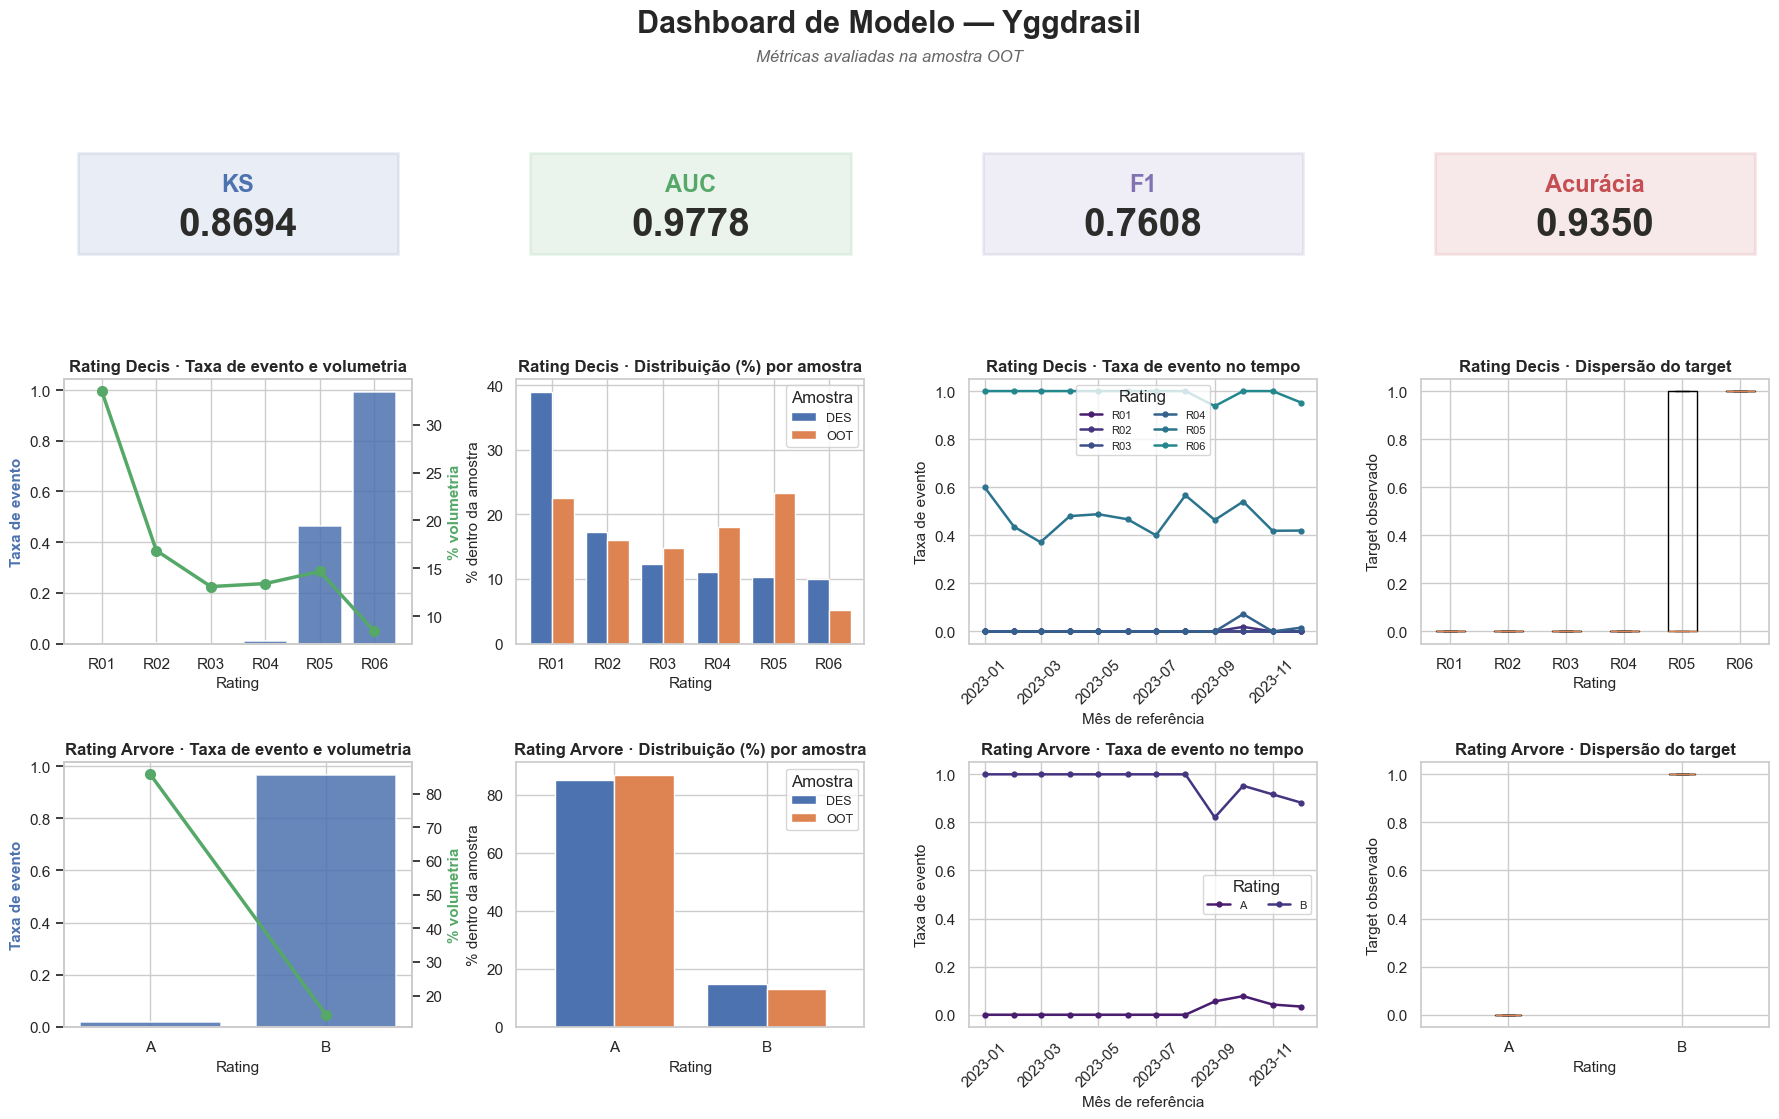

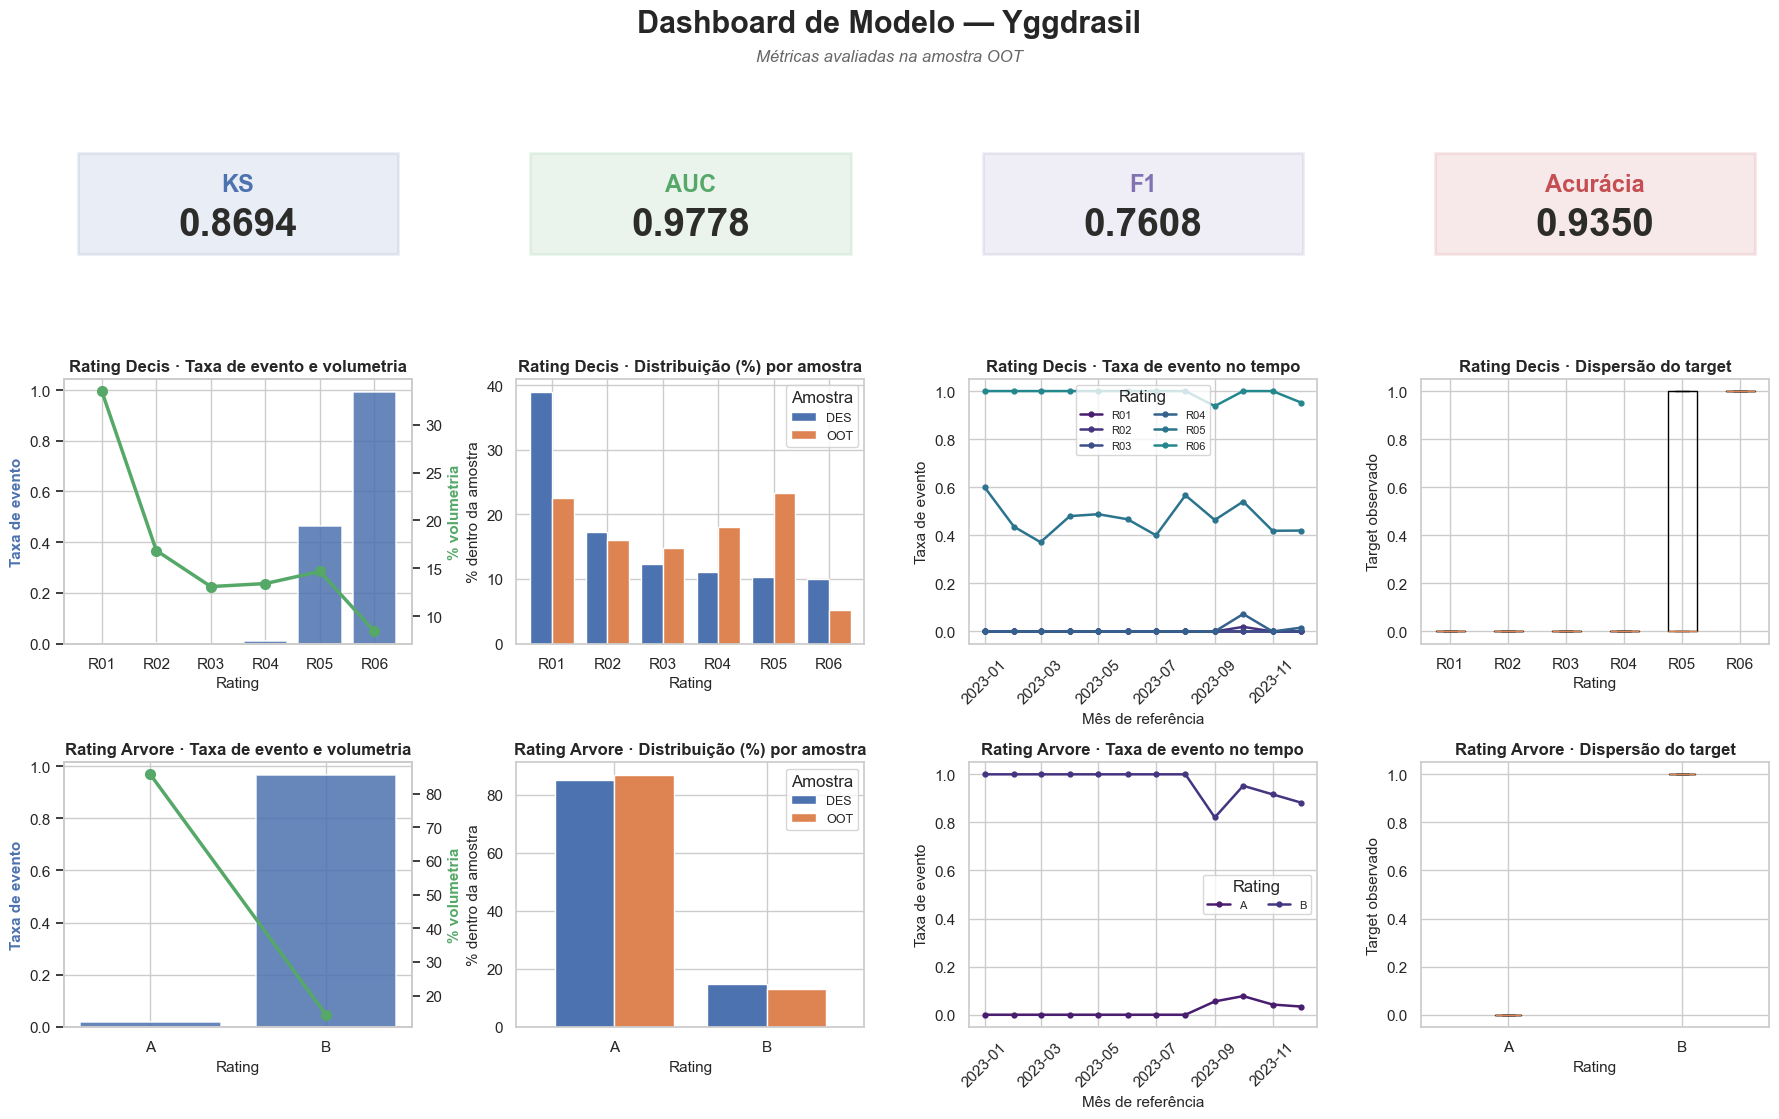

In [13]:
from yggdrasil.reporting import build_dashboard

fig = build_dashboard(df_analise, ["rating_decis", "rating_arvore"], cfg,
                      "classification", metrics=met.get("OOT", {}))
fig

## 9. Tudo de uma vez: `MLPipeline`

Na prática você não precisa orquestrar cada passo manualmente — o `MLPipeline.run()` faz tudo:
score, ratings, métricas, shifts, PSI, SHAP, relatórios **e loga no MLflow** num único run.

In [14]:
import mlflow
from yggdrasil import MLPipeline

mlflow.set_tracking_uri("file:./mlruns")

pipe = MLPipeline(cfg, problem_type="classification",
                  ratings=["decis", "quantil", "arvore", "optbin"])
resultado = pipe.run(df, model=model, experiment="tutorial_yggdrasil",
                     run_name="tutorial", tags={"autor": "richard"})

print("run_id:", resultado.run_id)
print("Métricas por amostra:")
display(pd.DataFrame(resultado.metrics_by_sample).T)

2026/06/14 00:55:53 INFO mlflow.tracking.fluent: Experiment with name 'tutorial_yggdrasil' does not exist. Creating a new experiment.


Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


 10%|==                  | 419/4000 [00:11<01:34]       

 12%|==                  | 468/4000 [00:12<01:30]       

 13%|===                 | 512/4000 [00:13<01:28]       

...

100%|===================| 3984/4000 [01:44<00:00]       

2026/06/14 00:57:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/14 00:57:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


run_id: 9ac8f683ecc943dfa273c6f16e057134
Métricas por amostra:


,auc,gini,ks,ks_cutoff,accuracy,f1,precision,recall,brier,logloss
DES,1.0000,1.0000,1.0000,0.6067,1.0000,1.0000,1.0000,1.0000,0.0050,0.0364
OOT,0.9778,0.9555,0.8694,0.6067,0.9350,0.7608,0.9496,0.6346,0.0420,0.1457


## 10. Amostras *scoring-only* (`SIMUL`/`BACKTEST`)

Essas amostras **recebem score e grupo homogêneo**, mas ficam **fora** de toda análise
(métricas, shifts, PSI, relatórios). Repare que `SIMUL` aparece no DataFrame final scorado,
mas **não** nas chaves de `metrics_by_sample`.

In [15]:
print("Amostras com análise:", list(resultado.metrics_by_sample.keys()))
print("SIMUL no resultado scorado (com score + ratings):")
display(
    resultado.df_scored[resultado.df_scored["amostra"] == "SIMUL"]
    [["amostra", cfg.score_col] + resultado.rating_cols].head()
)

Amostras com análise: ['DES', 'OOT']
SIMUL no resultado scorado (com score + ratings):


,amostra,prediction,rating_decis,rating_quantil,rating_arvore,rating_optbin
6,SIMUL,0.0600,R04,C,A,A
17,SIMUL,0.9867,R06,G,B,A
79,SIMUL,0.2933,R05,D,A,A
94,SIMUL,0.0067,R02,B,A,A
98,SIMUL,0.0133,R03,B,A,A


## 11. Visualizando no MLflow

Os runs ficam em `./mlruns`. Para abrir a interface:

```bash
mlflow ui --backend-store-uri ./mlruns
```

Lá você encontra, por run: as métricas `*_des`/`*_oot`, os `*_shift_*`, o `psi_*`, e os artefatos
em `reports/` (relatórios por grupo + HTML), `psi/` (séries temporais), `dashboard/` e `shap/`.

No **Databricks**, troque a carga de dados por `spark.read.table(...).toPandas()` e use um
`experiment` no padrão do workspace (ex.: `/Shared/Yggdrasil/pd_pf`) — o tracking já é gerenciado.

**Próximos passos:** veja o notebook orquestrador pronto para produção em
`notebooks/03_modeling/01_esteira_ml_mlflow.ipynb`.